# **1. Perkenalan Dataset**


https://www.kaggle.com/datasets/yadiraespinoza/world-happiness-2015-2024/data?select=world_happiness_combined.csv

Dataset yang digunakan adalah World Happiness Report 2015–2024 yang berisi data indikator sosial dan ekonomi berbagai negara.
Tujuan eksperimen ini adalah membangun model machine learning untuk memprediksi skor kebahagiaan (Life Ladder) berdasarkan faktor-faktor tersebut.

Pada dataset ini, variabel target yang digunakan adalah Happiness score, yang merepresentasikan tingkat kebahagiaan suatu negara berdasarkan World Happiness Report.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pandas as pd

path = "/content/drive/MyDrive/MSML_DATA/world_happiness_combined.csv"
df = pd.read_csv(path, sep=";")

df.head()


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,"7,58700","8,26132","0,96240",73,"0,99379","0,37289","0,23941",2015
1,2,Iceland,Western Europe,"7,56100","7,70416","1,00000",73,"0,93884","0,54819","0,74371",2015
2,3,Denmark,Western Europe,"7,52700","7,84114","0,97030",70,"0,96962","0,42894","0,12382",2015
3,4,Norway,Western Europe,"7,52200","8,63100","0,94917",71,"1,00000","0,43598","0,33860",2015
4,5,Canada,North America and ANZ,"7,42700","7,84595","0,94322",71,"0,94511","0,57560","0,40285",2015


In [6]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Ranking                       1502 non-null   int64 
 1   Country                       1502 non-null   object
 2   Regional indicator            1499 non-null   object
 3   Happiness score               1502 non-null   object
 4   GDP per capita                1502 non-null   object
 5   Social support                1502 non-null   object
 6   Healthy life expectancy       1502 non-null   int64 
 7   Freedom to make life choices  1502 non-null   object
 8   Generosity                    1502 non-null   object
 9   Perceptions of corruption     1502 non-null   object
 10  Year                          1502 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 129.2+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Dataset terdiri dari sejumlah baris dan kolom yang merepresentasikan indikator kebahagiaan lintas negara dan tahun.

In [8]:
df.shape
df.columns


Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Year'],
      dtype='object')

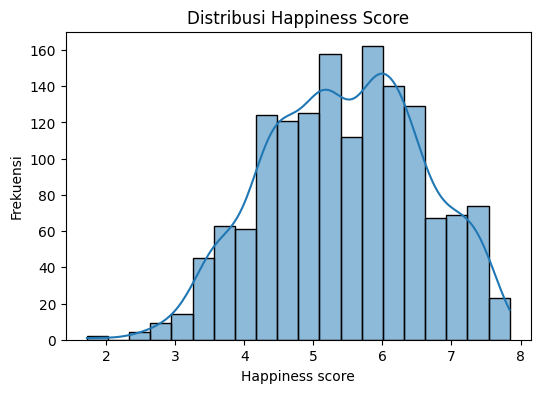

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(
    df["Happiness score"],
    bins=20,
    kde=True
)
plt.title("Distribusi Happiness Score")
plt.xlabel("Happiness score")
plt.ylabel("Frekuensi")
plt.show()


Visualisasi distribusi Happiness score menunjukkan sebaran nilai yang relatif stabil tanpa adanya outlier ekstrem. Nilai target tersebar pada rentang tertentu dan tidak menunjukkan skewness yang berlebihan, sehingga pendekatan regresi dinilai sesuai untuk memodelkan data ini.

In [10]:
df.isna().sum().sort_values(ascending=False)


,0
Regional indicator,3
Ranking,0
Country,0
Happiness score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


Hasil analisis menunjukkan bahwa hanya terdapat sejumlah kecil nilai kosong (3 baris) pada kolom Regional indicator, sementara fitur utama dan variabel target tidak memiliki missing value.
Untuk menjaga konsistensi pipeline preprocessing dan memastikan data siap digunakan pada tahap otomatisasi dan deployment, penanganan missing value tetap dilakukan pada tahap preprocessing.

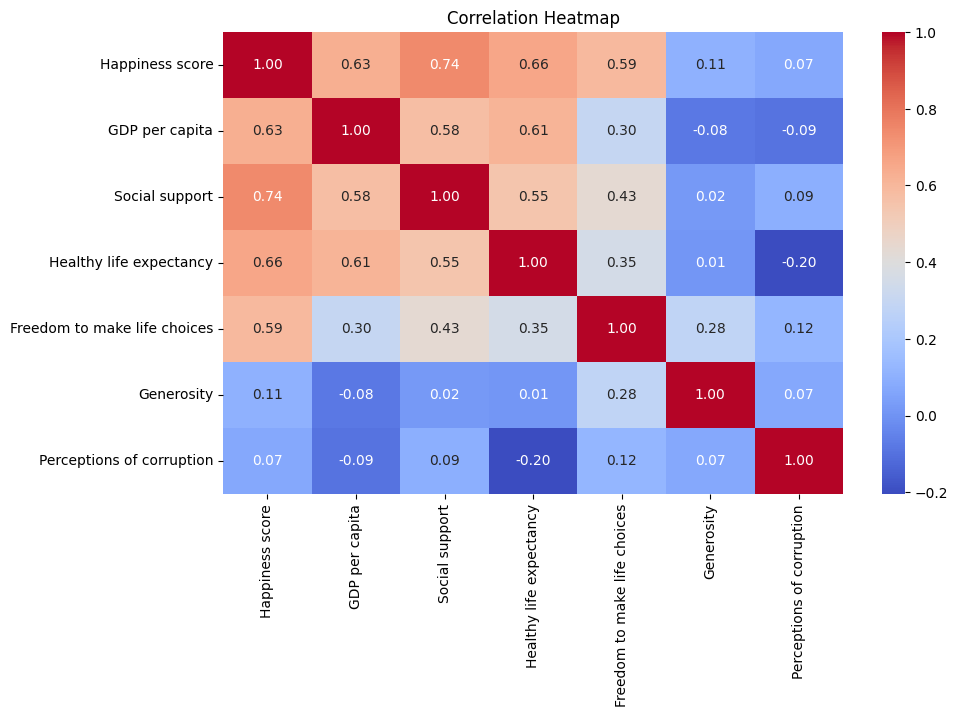

In [12]:
for col in [
    "Happiness score",
    "GDP per capita",
    "Social support",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]:
    df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

plt.figure(figsize=(10,6))
sns.heatmap(
    df[[
        "Happiness score",
        "GDP per capita",
        "Social support",
        "Healthy life expectancy",
        "Freedom to make life choices",
        "Generosity",
        "Perceptions of corruption"
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Analisis korelasi menunjukkan bahwa beberapa variabel memiliki hubungan yang cukup kuat dengan Happiness score.
Variabel Social support (0.74), Healthy life expectancy (0.66), dan GDP per capita (0.63) menunjukkan korelasi positif yang relatif tinggi, sehingga berpotensi menjadi prediktor utama.
Sementara itu, variabel Generosity dan Perceptions of corruption memiliki korelasi yang lebih rendah terhadap target, namun tetap dipertahankan untuk menangkap pengaruh non-linear yang mungkin tidak terlihat melalui korelasi linear.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
# Menentukan target dan fitur
target = "Happiness score"

features = [
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]

X = df[features]
y = df[target]

X.head(), y.head()


(   GDP per capita  Social support  Healthy life expectancy  \
 0         8.26132         0.96240                       73   
 1         7.70416         1.00000                       73   
 2         7.84114         0.97030                       70   
 3         8.63100         0.94917                       71   
 4         7.84595         0.94322                       71   
 
    Freedom to make life choices  Generosity  Perceptions of corruption  
 0                       0.99379     0.37289                    0.23941  
 1                       0.93884     0.54819                    0.74371  
 2                       0.96962     0.42894                    0.12382  
 3                       1.00000     0.43598                    0.33860  
 4                       0.94511     0.57560                    0.40285  ,
 0    7.587
 1    7.561
 2    7.527
 3    7.522
 4    7.427
 Name: Happiness score, dtype: float64)

Fitur dipilih berdasarkan hasil analisis korelasi dan relevansinya terhadap skor kebahagiaan.

In [15]:
X.dtypes


,0
GDP per capita,float64
Social support,float64
Healthy life expectancy,int64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


In [16]:
# Handle missing values
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [17]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [18]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((1201, 6), (301, 6))

Data dibagi menjadi data latih dan uji dengan rasio 80:20 untuk mengevaluasi performa model secara objektif.

In [19]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)